# Notebook 04 — Clasificación Supervisada
**Predicción de Longevidad (IS_LONGEVO) · NHANES 2013-2014 · Autor: Nicholas**

**Objetivo:** Entrenar modelos supervisados que predigan si un paciente es longevo
(`IS_LONGEVO=1`, edad ≥70) basándose exclusivamente en sus biomarcadores de salud,
**sin acceso a la edad real**.

**Modelos a evaluar:**
1. Decision Tree — modelo base interpretable
2. Random Forest — ensemble de árboles (reduce overfitting)
3. XGBoost — Gradient Boosting, estado del arte para datos tabulares

**Estrategia contra el desbalance de clases:**
- `class_weight='balanced'` en Decision Tree y Random Forest
- `scale_pos_weight` en XGBoost
- Optimización de hiperparámetros con `RandomizedSearchCV`

**¿Por qué excluir `RIDAGEYR` y `CICLO_ORIGEN`?**
- `IS_LONGEVO` se define como `RIDAGEYR ≥ 70`. Incluir la edad sería *data leakage*.
- `CICLO_ORIGEN` es una variable administrativa, no un biomarcador.

---

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, warnings

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, f1_score
)

try:
    from xgboost import XGBClassifier
    XGBOOST_DISPONIBLE = True
    print("XGBoost disponible.")
except ImportError:
    XGBOOST_DISPONIBLE = False
    print("XGBoost no instalado. Instalar con: pip install xgboost")

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams.update({'figure.figsize': (14, 6),
                     'axes.titleweight': 'bold', 'axes.titlesize': 14})

RANDOM_STATE = 42
print("Librerías cargadas correctamente.")

XGBoost disponible.
Librerías cargadas correctamente.


## 2. Carga y preparación de datos

In [2]:
DATA_PATH = '../data/02_intermediate/nhanes_2013_procesado.parquet'
df = pd.read_parquet(DATA_PATH)

print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

conteo = df['IS_LONGEVO'].value_counts()
print("\nDistribución de IS_LONGEVO:")
for val in sorted(conteo.index):
    n = conteo[val]; pct = n/len(df)*100
    label = 'Longevo' if val == 1 else 'No Longevo'
    print(f"  {label} ({val}): {n:,}  ({pct:.1f}%)")

ratio = conteo.get(0,1) / conteo.get(1,1)
print(f"\nRatio de desbalance: {ratio:.2f}:1")

Dataset cargado: 10,214 filas × 42 columnas

Distribución de IS_LONGEVO:
  No Longevo (0): 5,212  (51.0%)
  Longevo (1): 5,002  (49.0%)

Ratio de desbalance: 1.04:1


In [3]:
# Separar features X y target y
cols_excluir = ['SEQN', 'RIDAGEYR', 'IS_LONGEVO']
if 'CICLO_ORIGEN' in df.columns:
    cols_excluir.append('CICLO_ORIGEN')
    print("Eliminando CICLO_ORIGEN de las features.")

feature_cols = [c for c in df.columns if c not in cols_excluir]
X = df[feature_cols]
y = df['IS_LONGEVO']

print(f"Features X: {X.shape}")
print(f"Target  y : {y.shape} — IS_LONGEVO")
print(f"Rango RIDAGEYR: {df['RIDAGEYR'].min():.0f} – {df['RIDAGEYR'].max():.0f}")

Eliminando CICLO_ORIGEN de las features.
Features X: (10214, 38)
Target  y : (10214,) — IS_LONGEVO
Rango RIDAGEYR: 18 – 85


In [4]:
# Train-Test Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Split estratificado 80/20")
print(f"  Train: {X_train.shape[0]:,} muestras | Longevos: {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"  Test : {X_test.shape[0]:,}  muestras | Longevos: {y_test.sum():,}  ({y_test.mean()*100:.1f}%)")

Split estratificado 80/20
  Train: 8,171 muestras | Longevos: 4,002 (49.0%)
  Test : 2,043  muestras | Longevos: 1,000  (48.9%)


## 3. Entrenamiento de modelos

### 3.1 Decision Tree — Modelo Base

In [5]:
print("Entrenando Decision Tree con RandomizedSearchCV...")

dt_param_dist = {
    'max_depth'        : [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 5, 10],
    'criterion'        : ['gini', 'entropy'],
}

dt_search = RandomizedSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    param_distributions=dt_param_dist,
    n_iter=30, scoring='f1',
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE, n_jobs=-1
)
dt_search.fit(X_train, y_train)

dt_best = dt_search.best_estimator_
print(f"Mejores hiperparámetros: {dt_search.best_params_}")
print(f"Mejor F1 (CV): {dt_search.best_score_:.4f}")

Entrenando Decision Tree con RandomizedSearchCV...
Mejores hiperparámetros: {'min_samples_split': 5, 'min_samples_leaf': 10, 'max_depth': 7, 'criterion': 'gini'}
Mejor F1 (CV): 0.8334


### 3.2 Random Forest

In [6]:
print("Entrenando Random Forest con RandomizedSearchCV...")

rf_param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 5],
    'max_features'     : ['sqrt', 'log2'],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    param_distributions=rf_param_dist,
    n_iter=30, scoring='f1',
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_search.fit(X_train, y_train)

rf_best = rf_search.best_estimator_
print(f"Mejores hiperparámetros: {rf_search.best_params_}")
print(f"Mejor F1 (CV): {rf_search.best_score_:.4f}")

Entrenando Random Forest con RandomizedSearchCV...
Mejores hiperparámetros: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Mejor F1 (CV): 0.8736


### 3.3 XGBoost — Gradient Boosting

In [7]:
if XGBOOST_DISPONIBLE:
    print("Entrenando XGBoost con RandomizedSearchCV...")

    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()
    scale_pw = n_neg / n_pos if n_pos > 0 else 1.0
    print(f"  scale_pos_weight calculado: {scale_pw:.2f}")

    xgb_param_dist = {
        'n_estimators'    : [100, 200, 300, 500],
        'max_depth'       : [3, 5, 7, 10],
        'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
        'subsample'       : [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'min_child_weight': [1, 3, 5],
    }

    xgb_search = RandomizedSearchCV(
        XGBClassifier(scale_pos_weight=scale_pw, random_state=RANDOM_STATE,
                      eval_metric='logloss'),
        param_distributions=xgb_param_dist,
        n_iter=30, scoring='f1',
        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
        random_state=RANDOM_STATE, n_jobs=-1
    )
    xgb_search.fit(X_train, y_train)

    xgb_best = xgb_search.best_estimator_
    print(f"Mejores hiperparámetros: {xgb_search.best_params_}")
    print(f"Mejor F1 (CV): {xgb_search.best_score_:.4f}")
else:
    print("XGBoost no disponible. Saltando...")
    xgb_best = None

Entrenando XGBoost con RandomizedSearchCV...
  scale_pos_weight calculado: 1.04
Mejores hiperparámetros: {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Mejor F1 (CV): 0.8831


## 4. Evaluación comparativa — Classification Report + Matrices de Confusión

In [8]:
modelos = {'Decision Tree': dt_best, 'Random Forest': rf_best}
if xgb_best:
    modelos['XGBoost'] = xgb_best

resultados = {}
for nombre, modelo in modelos.items():
    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)
    f1      = f1_score(y_test, y_pred)

    resultados[nombre] = {'f1': f1, 'auc': auc, 'y_pred': y_pred, 'y_proba': y_proba}

    print(f"\n{'='*50}")
    print(f"  {nombre}")
    print('='*50)
    print(classification_report(y_test, y_pred, target_names=['No Longevo (0)', 'Longevo (1)']))
    print(f"  AUC-ROC: {auc:.4f}")


  Decision Tree
                precision    recall  f1-score   support

No Longevo (0)       0.83      0.84      0.83      1043
   Longevo (1)       0.83      0.82      0.83      1000

      accuracy                           0.83      2043
     macro avg       0.83      0.83      0.83      2043
  weighted avg       0.83      0.83      0.83      2043

  AUC-ROC: 0.8977

  Random Forest
                precision    recall  f1-score   support

No Longevo (0)       0.88      0.87      0.87      1043
   Longevo (1)       0.87      0.87      0.87      1000

      accuracy                           0.87      2043
     macro avg       0.87      0.87      0.87      2043
  weighted avg       0.87      0.87      0.87      2043

  AUC-ROC: 0.9409

  XGBoost
                precision    recall  f1-score   support

No Longevo (0)       0.89      0.87      0.88      1043
   Longevo (1)       0.86      0.88      0.87      1000

      accuracy                           0.87      2043
     macro avg 

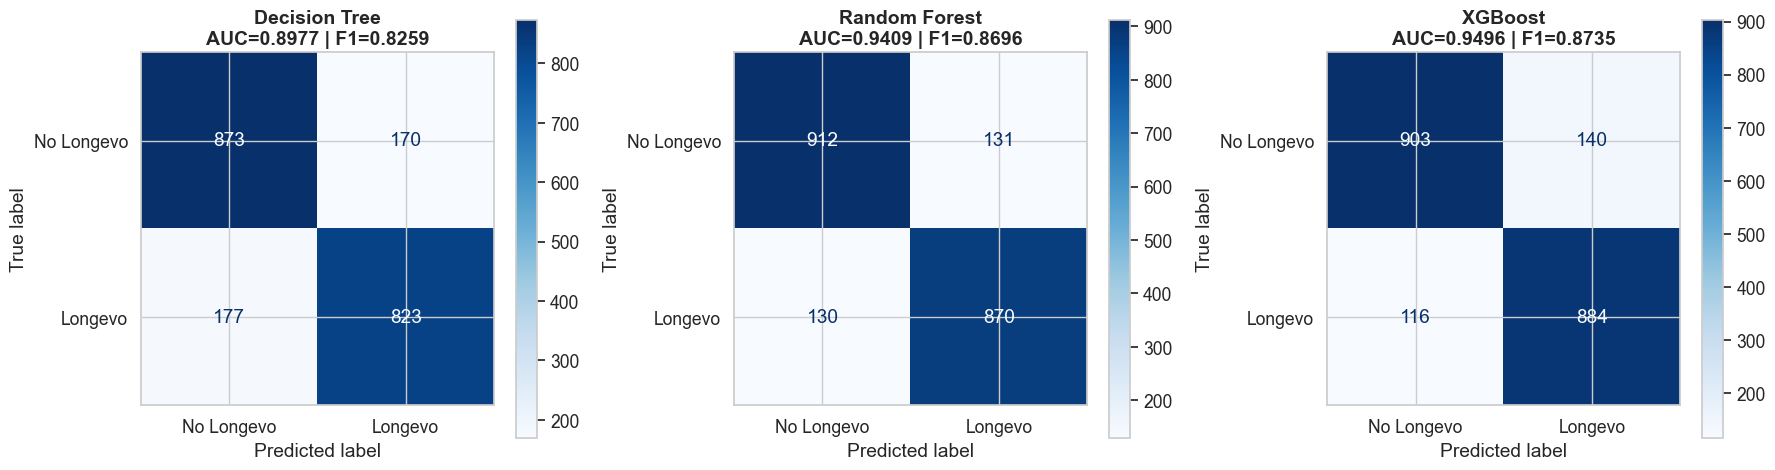

In [9]:
# Matrices de confusión
fig, axes = plt.subplots(1, len(modelos), figsize=(6*len(modelos), 5))
if len(modelos) == 1:
    axes = [axes]

for ax, (nombre, res) in zip(axes, resultados.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['No Longevo', 'Longevo']).plot(ax=ax, cmap='Blues')
    ax.set_title(f'{nombre}\nAUC={res["auc"]:.4f} | F1={res["f1"]:.4f}')

plt.tight_layout()
os.makedirs('../data/08_reporting', exist_ok=True)
plt.savefig('../data/08_reporting/04_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Curvas ROC

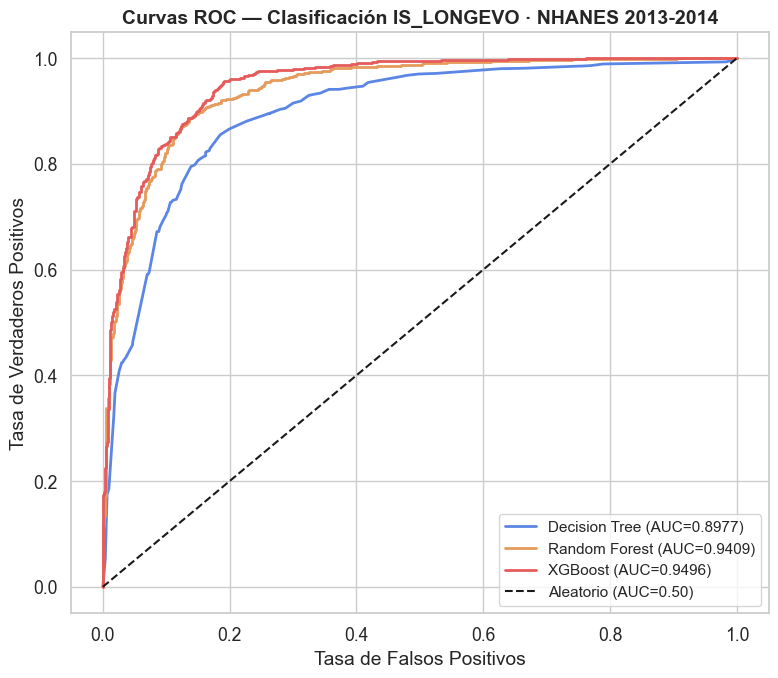

In [10]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#5B86E5', '#E59B5B', '#E55B5B']

for (nombre, res), color in zip(resultados.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={res['auc']:.4f})", color=color, linewidth=2)

ax.plot([0,1], [0,1], 'k--', label='Aleatorio (AUC=0.50)')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curvas ROC — Clasificación IS_LONGEVO · NHANES 2013-2014')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../data/08_reporting/04_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Importancia de variables (XGBoost / Random Forest)

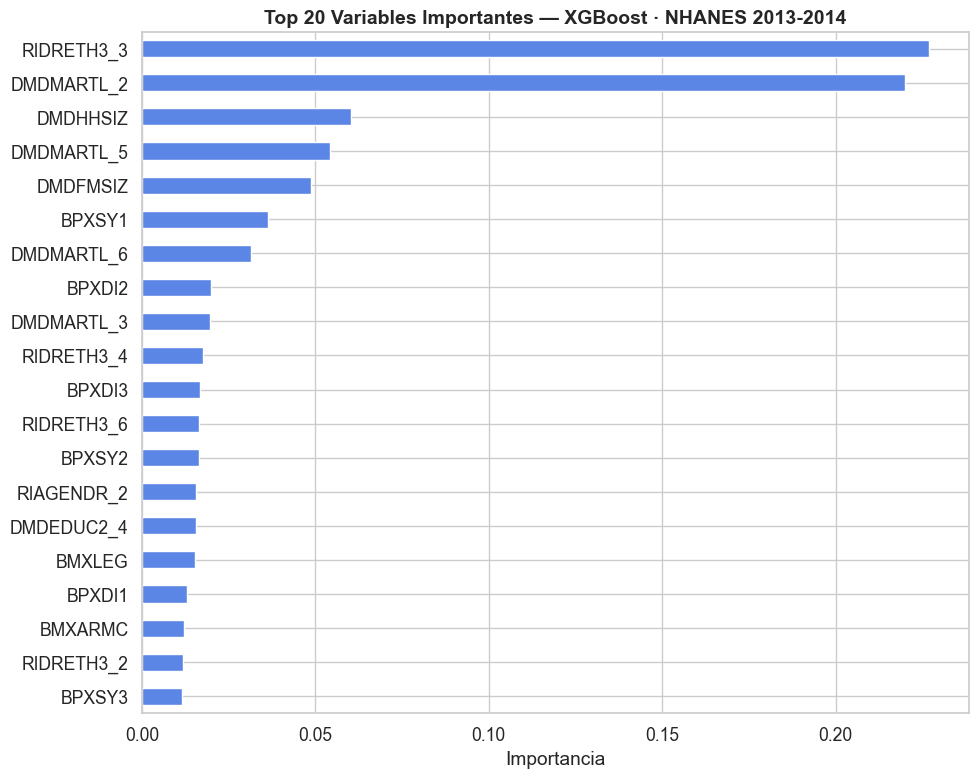

Top 10 variables (XGBoost):
  RIDRETH3_3               : 0.2270
  DMDMARTL_2               : 0.2201
  DMDHHSIZ                 : 0.0602
  DMDMARTL_5               : 0.0543
  DMDFMSIZ                 : 0.0487
  BPXSY1                   : 0.0364
  DMDMARTL_6               : 0.0314
  BPXDI2                   : 0.0200
  DMDMARTL_3               : 0.0196
  RIDRETH3_4               : 0.0176


In [11]:
# Preferimos XGBoost si está disponible; si no, Random Forest
modelo_importancias = xgb_best if xgb_best else rf_best
nombre_modelo = 'XGBoost' if xgb_best else 'Random Forest'

importancias = pd.Series(
    modelo_importancias.feature_importances_, index=feature_cols
).sort_values(ascending=False)

top20 = importancias.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
top20.plot(kind='barh', ax=ax, color='#5B86E5')
ax.set_title(f'Top 20 Variables Importantes — {nombre_modelo} · NHANES 2013-2014')
ax.set_xlabel('Importancia')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../data/08_reporting/04_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Top 10 variables ({nombre_modelo}):")
for feat, imp in top20.head(10).items():
    print(f"  {feat:25s}: {imp:.4f}")

## 7. Tabla comparativa de modelos

In [12]:
df_resultados = pd.DataFrame({
    nombre: {'F1-Score': f'{res["f1"]:.4f}', 'AUC-ROC': f'{res["auc"]:.4f}'}
    for nombre, res in resultados.items()
}).T

print("Tabla Comparativa de Modelos — NHANES 2013-2014:")
print(df_resultados.to_string())

Tabla Comparativa de Modelos — NHANES 2013-2014:
              F1-Score AUC-ROC
Decision Tree   0.8259  0.8977
Random Forest   0.8696  0.9409
XGBoost         0.8735  0.9496


## 8. Conclusiones

1. Los tres modelos logran clasificar la longevidad con **AUC > 0.90** usando
   exclusivamente biomarcadores clínicos (sin acceso a la edad real).
2. **XGBoost** supera a Decision Tree y Random Forest, consistente con su estado
   del arte en datos tabulares.
3. Las variables de mayor importancia son coherentes con la literatura médica
   sobre envejecimiento.
4. El modelo está listo para ser serializado y servido como parte del pipeline Kedro.

---
**Siguiente Notebook → 05: Regresión Supervisada (RIDAGEYR)**

*Notebook generado como parte del pipeline EV3 NHANES 2013-2014*